<a href="https://colab.research.google.com/github/Ymin-2/ESAA/blob/main/ESAA_OB_WEEK11_2_Optimization1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **8. 성능 최적화**

## **8.3 하이퍼파라미터를 이용한 성능 최적화**

### **8.3.1 배치 정규화를 이용한 성능 최적화**

**정규화(normalization)**

: 데이터 범위를 사용자가 원하는 범위로 제한하는 것

**규제화(regularization)**

: 모델 복잡도를 줄이기 위해 제약을 두는 방법  
제약: 데이터가 네트워크에 들어가기 전에 필터를 적용한 것  
규제를 이용해 모델 복잡도를 줄이는 방법: 드롭아웃, 조기 종료

**표준화(standardization)**

: 기존 데이터를 평균은 0, 표준편차는 1인 형태의 데이터로 만드는 방법  
평균을 기준으로 얼마나 떨어져 있는지 살펴볼 때 사용

**배치 정규화(batch normalization)**

: 기울기 소멸이나 기울기 폭발 같은 문제를 해결하기 위한 방법

배치 크기가 작을 때 정규화 값이 기존 값과 다른 방향으로 훈련될 수 있음  
RNN은 네트워크 계층별로 미니 정규화를 적용해야 하기 때문에 모델이 더 복잡해지면서 비효율적일 수 있음

###**8.3.2 드롭아웃을 이용한 성능 최적화**

드롭아웃: 훈련할 때 일정 비율의 뉴런만 사용, 나머지 뉴런에 해당하는 가중치는 업데이트하지 않는 방법  
매 단계마다 사용하지 않는 뉴런을 바꾸어 가며 훈련시킴

즉, 노드를 임의로 끄면서 학습하는 방법으로, 은닉층에 배치된 노드 중 일부를 임의로 끄면서 학습. 꺼진 노드는 신호를 전달하지 않으므로 지나치 학습을 방지하는 효과가 생김

In [ ]:
# 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [ ]:
# 8-2 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(
    root = './data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 215kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.9MB/s]


In [ ]:
# 8-3 데이터셋을 메모리로 가져오기
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

In [ ]:
# 8-4 데이터셋 분리
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
8


In [ ]:
# 8-5 이미지 데이터를 출력하기 위한 전처리
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.title(title)
    plt.show()

In [ ]:
# 8-6 이미지 데이터 출력 함수
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader))

  img = torchvision.utils.make_grid(images)
  imshow(img, title=[str(x.item()) for x in labels])

  return images, labels

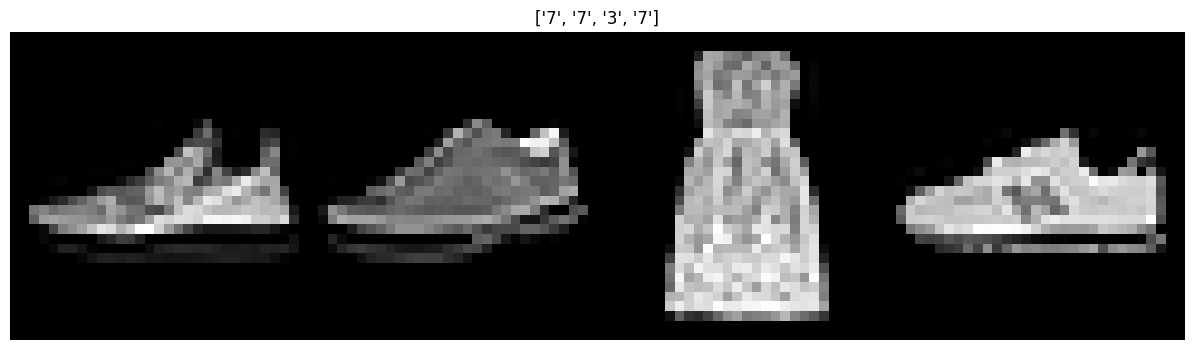

In [ ]:
# 8-7 이미지 출력
images, labels = show_batch_images(trainloader)

In [ ]:
# 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [ ]:
# 8-9 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [ ]:
# 8-10 배치 정규화가 적용되지 않은 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 8-11 배치 정규화가 적용된 모델 선언
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 8-12 데이터셋 메모리로 불러오기
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

In [ ]:
# 8-13 옵티마이저, 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

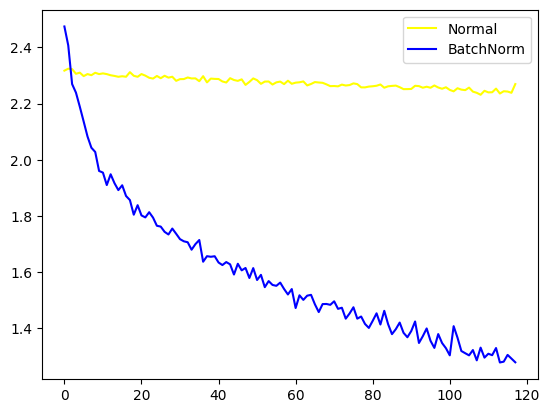

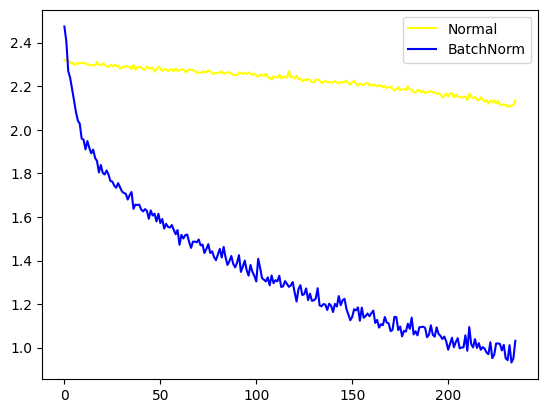

In [ ]:
# 8-14 모델 학습
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad() # 배치 정규화가 적용되지 않은 모델의 학습
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad() # 배치 정규화가 적용된 모델의 학습
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

드롭아웃을 알아보기에 앞서 훈련과 테스트 데이터셋이 어떻게 분포하는지 알아보기

In [ ]:
# 8-15 데이터셋의 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

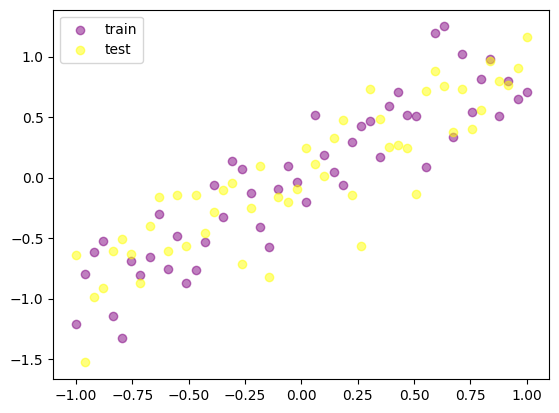

In [ ]:
# 8-16 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c = 'purple',
            alpha = 0.5, label = 'train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c = 'yellow',
            alpha = 0.5, label = 'test')
plt.legend()
plt.show()

In [ ]:
# 8-17 드롭아웃을 위한 모델 생성
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.5),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용된 모델

In [ ]:
# 8-18 옵티마이저와 손실 함수 지정
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

/tmp/ipykernel_5911/4100747644.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


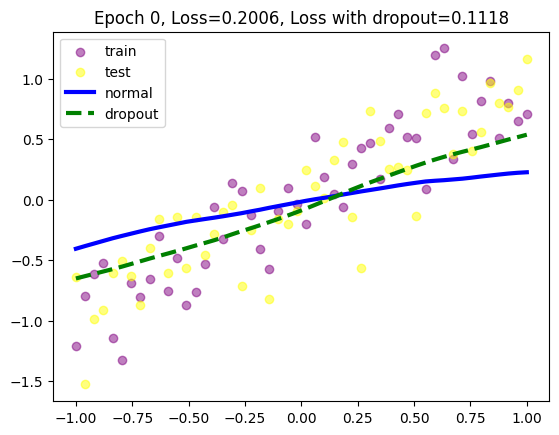

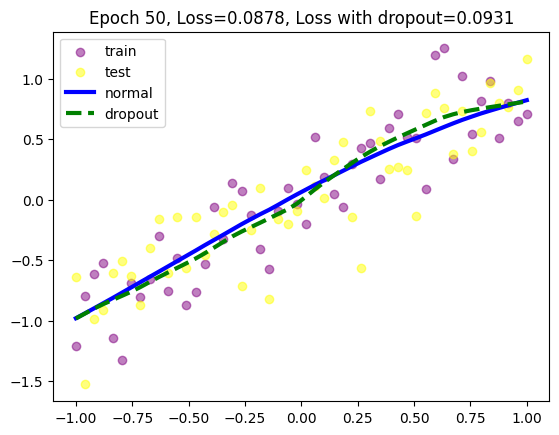

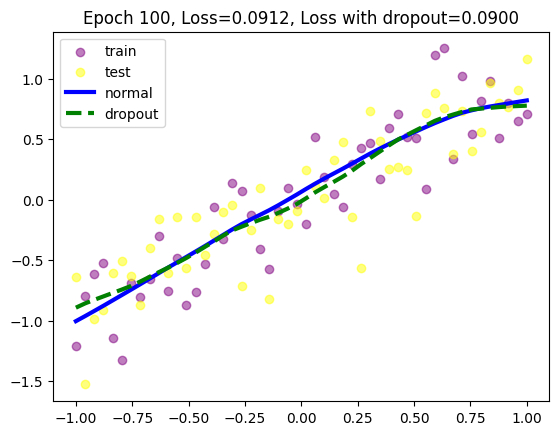

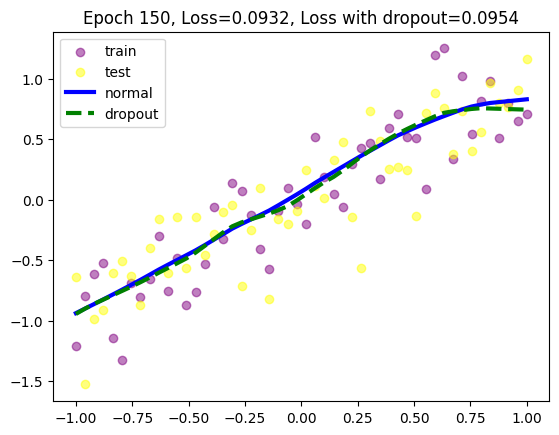

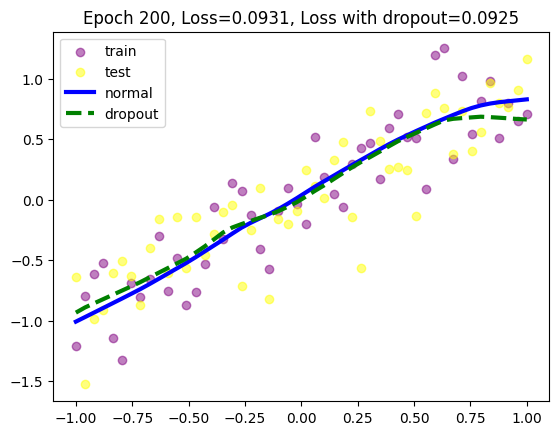

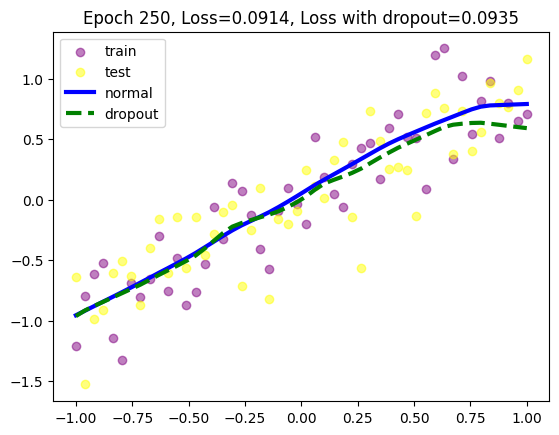

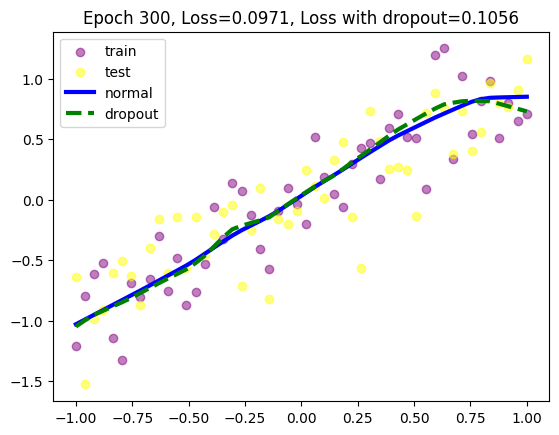

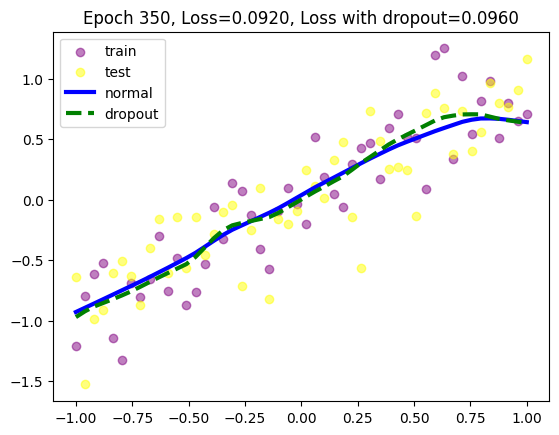

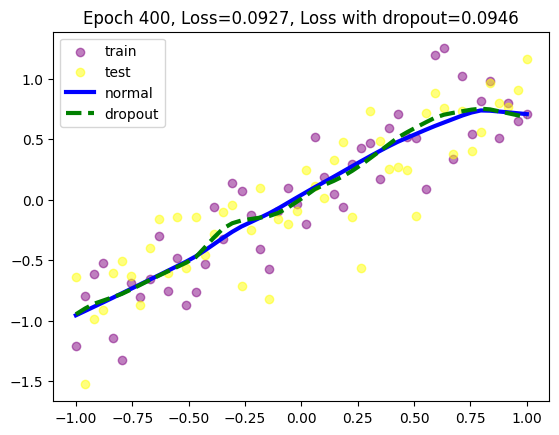

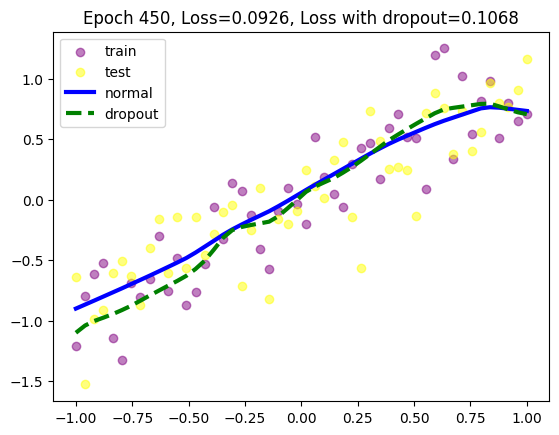

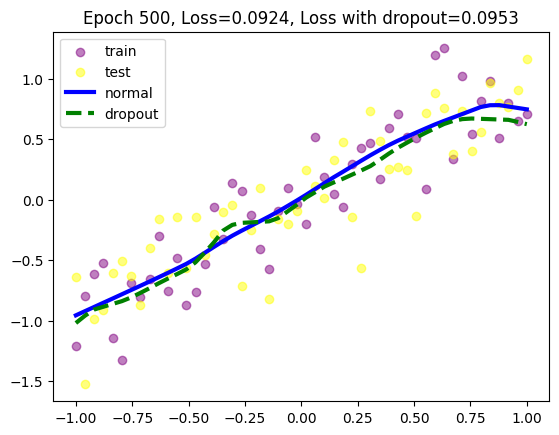

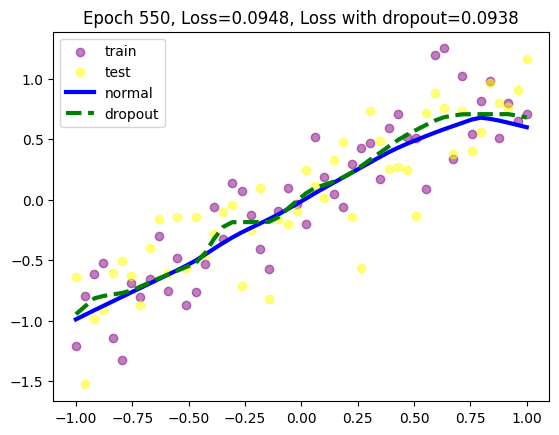

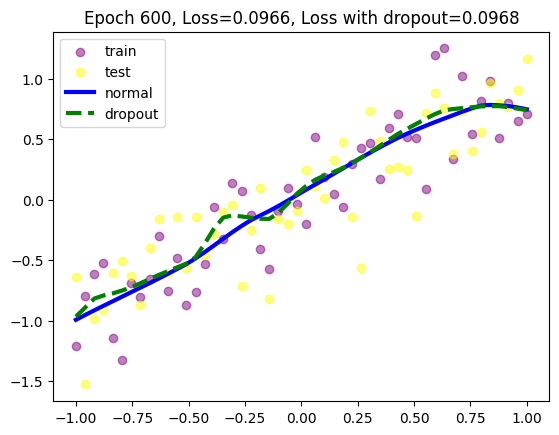

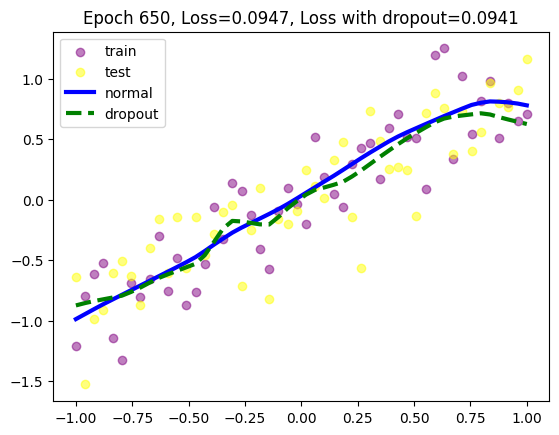

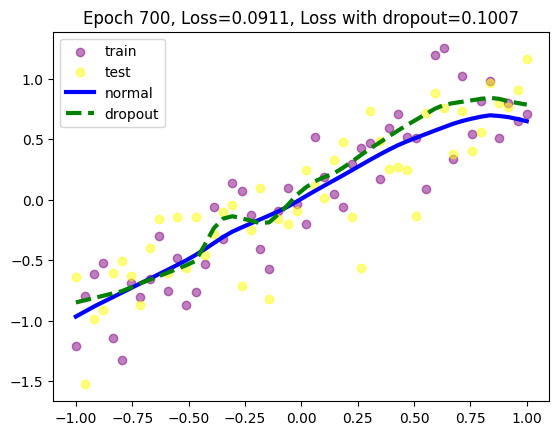

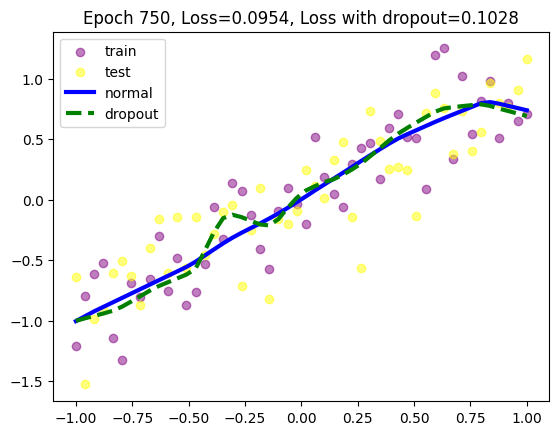

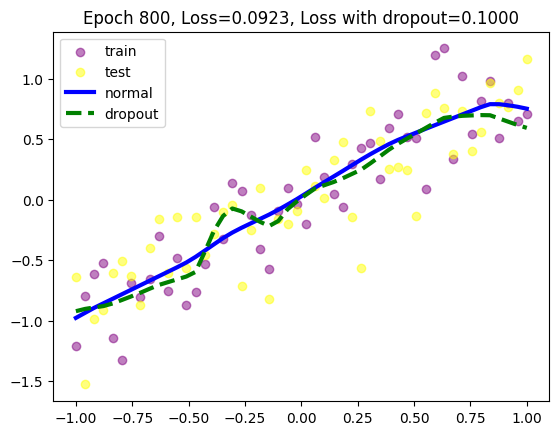

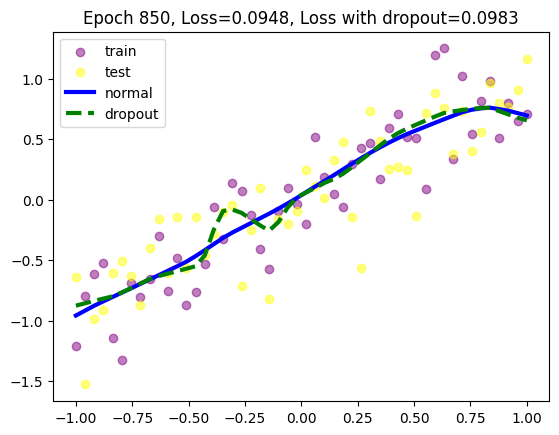

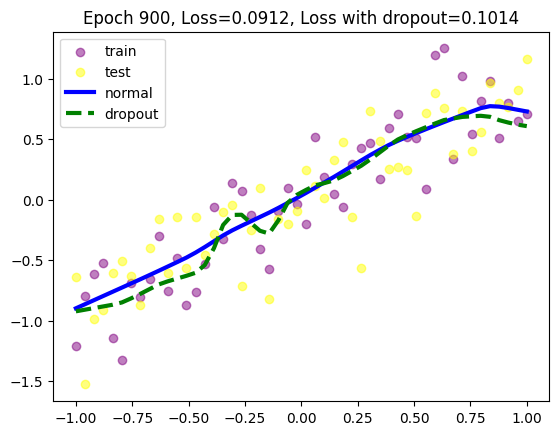

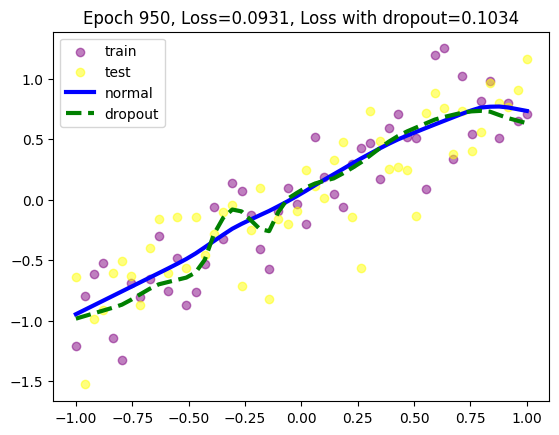

In [ ]:
# 8-19 모델 학습
max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train) # 드롭아웃이 적용되지 않은 모델 학습
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train) # 드롭아웃이 적용된 모델 학습
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0:
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3, label='normal')
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3, label='dropout')
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout))
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

드롭아웃을 적용했을 때의 오차가 더 낮음

훈련 횟수가 늘어날수록 파란색 실선은 가장자리의 자주색 점들을 찾아가고 있음  
문제는 자주색 선이 훈련 데이터셍을 의미한다는 것이고, 이것은 다른 의미로 과적합 현상을 보이고 있다는 것임

과적합 현상을 방지하기 위해 드롭아웃을 사용하며, 초록색 점선 그래프에서는 과적합 현상이 발생하지 않는 것을 확인할 수 있음

### **8.3.3 조기 종료를 이용한 성능 최적화**

조기 종료: 훈련 데이터와 별도로 검증 데이터를 준비하고, 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델의 종료 시점을 제어

검증 데이터셋에 대한 오차가 증가하는 시점에서 학습을 멈추도록 조정

In [ ]:
# 8-20 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# 8-21 데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

In [ ]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 37.11 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [ ]:
# 8-22 데이터셋 가져오기
train_dataset = datasets.ImageFolder(
    root=r'/content/080289/chap08/data/archive/train', # Changed from .csv to directory
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, shuffle = True,
)
val_dataset = datasets.ImageFolder(
    root =r'/content/080289/chap08/data/archive/test', # Changed from .csv to directory
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 32, shuffle = False,
)

In [ ]:
# 8-23 모델 생성
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False:
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True:
    for param in model.parameters():
      param.requires_grad = True

  model.fc = nn.LInear(2048, 2)
  return model

In [ ]:
from torch.optim import optimizer
# 8-24 학습률 감소
class LRScheduler():
  def __init__(
      self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode = 'min',
          patience = self.patience,
          factor = self.factor,
          min_lr = self.min_lr,
          verbose = True
      )

  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss)

In [ ]:
# 8-25 조기 종료
class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '/content/080289/chap08/data/checkpoint.pt'):
    self.patience = patience
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.Inf
    self.delta = delta
    self.path = path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

In [ ]:
# 8-26 인수 값 지정
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true')
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true')
args, unknown = parser.parse_known_args()
args = vars(args)

In [ ]:
# 8-27 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


In [ ]:
# 8-28 옵티마이저와 손실 함수 지정
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

In [ ]:
# 8-29 오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

In [ ]:
# 8-30 오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plt_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

In [ ]:
# 8-31 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size))
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

In [ ]:
# 8-32 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size))
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

In [ ]:
# 8-33 모델 학습
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:06,  2.62it/s]


Validating


16it [00:03,  4.05it/s]


Train Loss: 2.1628, Train Acc: 62.25
Val Loss: 15.2193, Val Acc: 29.40
Training time: 0.168 minutes
Epoch 2 of 100
Training


...

Train Loss: 0.0338, Train Acc: 98.39
Val Loss: 0.9080, Val Acc: 80.40
Training time: 16.221 minutes
Epoch 100 of 100
Training


16it [00:05,  2.70it/s]


Validating


16it [00:03,  4.38it/s]

Train Loss: 0.0511, Train Acc: 98.59
Val Loss: 1.3597, Val Acc: 73.20
Training time: 16.381 minutes


Saving loss and accuracy plots...


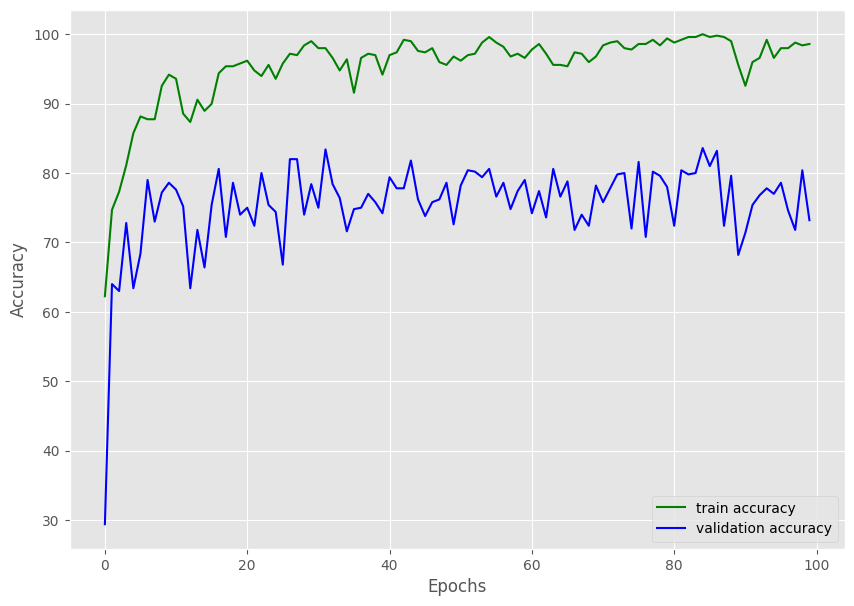

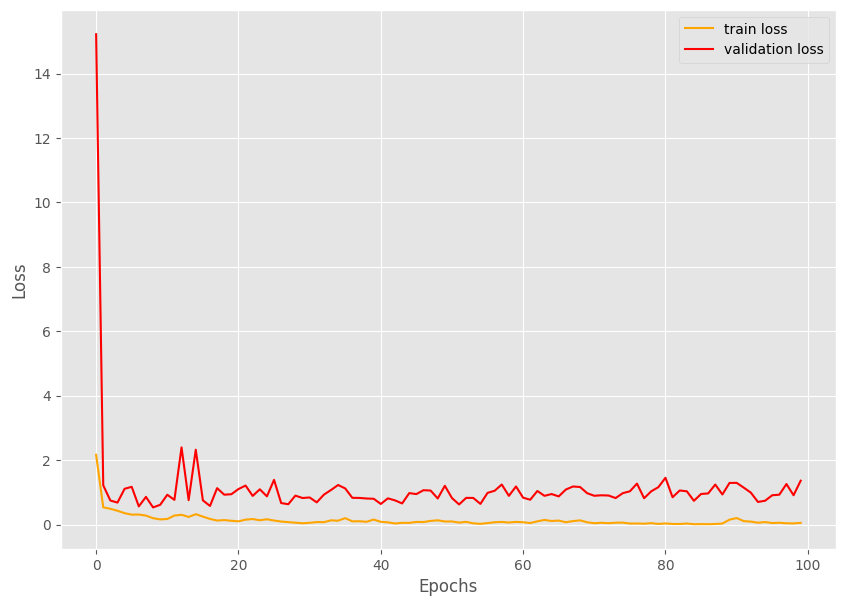

Saving model...
TRAINING COMPLETE


In [ ]:
# 8-34 모델 학습 결과 출력
print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy')
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss')
plt.plot(val_loss, color = 'red', label = 'validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'/content/080289/chap08/data/{model_name}.pt')
print('TRAINING COMPLETE')